In [ ]:
import torch
import os
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import timm
import huggingface_hub

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt 

from timm import create_model  # or torchvision.models
from tqdm.notebook import tqdm
from torchinfo import summary
from pipeline_func import set_seed, eeg_from_parquet, get_lr_lambda, butter_lowpass_filter, test_eeg_dataset, EEG_dataset, EEGModel

from torch.utils.data import DataLoader, random_split
# Frank Hu
# 8-8-2025


In [2]:

# Automatically detect the best device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [3]:
class CFG:
    verbose = 1  # Verbosity
    seed = 42  # Random seed
    preset = "efficientnetv2_l"  # Name of pretrained classifier
    image_size = [400, 300]  # Input image size
    epochs = 13 # Training epochs
    batch_size = 8  # Batch size
    lr_mode = "cos" # LR scheduler mode from one of "cos", "step", "exp"
    drop_remainder = True  # Drop incomplete batches
    num_classes = 6 # Number of classes in the dataset
    fold = 0 # Which fold to set as validation eeg
    class_names = ['Seizure', 'LPD', 'GPD', 'LRDA','GRDA', 'Other']
    label2name = dict(enumerate(class_names))
    name2label = {v:k for k, v in label2name.items()}
    output_dir = "./effnet_result"
    create_eeg = False

In [4]:
set_seed(CFG.seed)

In [5]:
train = pd.read_csv('./Data/train.csv')
print( train.shape )
display( train.head() )

(106800, 15)


,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


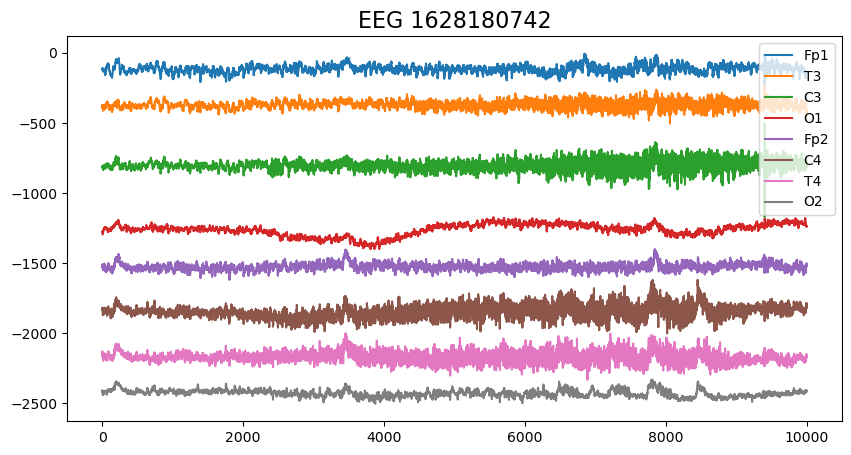

Reading 17089 eeg NumPys from disk.
CPU times: total: 1.02 s
Wall time: 5.94 s


In [6]:
%%time

all_eegs = {}
DISPLAY = 1
EEG_IDS = train.eeg_id.unique()
PATH = './Data/train_eegs/'

eegs_20 = {}
subset_size = int(len(EEG_IDS) * 0.2)
EEG_IDS_20 = EEG_IDS[:subset_size]

for i,eeg_id in enumerate(EEG_IDS_20):
    if (i%100==0)&(i!=0): print(i,', ',end='') 
    
    # SAVE EEG TO PYTHON DICTIONARY OF NUMPY ARRAYS
    eeg = eeg_from_parquet(f'{PATH}{eeg_id}.parquet', display=i<DISPLAY)              
    eegs_20[eeg_id] = eeg
    
    if i==DISPLAY:
        if CFG.create_eeg:
            print(f'Processing {train.eeg_id.nunique()} eeg parquets... ',end='')
        else:
            print(f'Reading {len(EEG_IDS)} eeg NumPys from disk.')
            break

if CFG.create_eeg:
    os.makedirs('./tmp/eeg_time', exist_ok=True) 
    np.save('./tmp/eeg_time/eegs_20',eegs_20)
else:
    eegs_20 = np.load('./tmp/eeg_time/eegs_20.npy',allow_pickle=True).item()
 

In [7]:
# LOAD TRAIN 
TARGETS = train.columns[-6:]
TARS = {'Seizure':0, 'LPD':1, 'GPD':2, 'LRDA':3, 'GRDA':4, 'Other':5}
TARS2 = {x:y for y,x in TARS.items()}

corrected_train = train.groupby('eeg_id')[['patient_id']].agg('first')

tmp = train.groupby('eeg_id')[TARGETS].agg('sum')
for t in TARGETS:
    corrected_train[t] = tmp[t].values
    
y_data = corrected_train[TARGETS].values
y_data = y_data / y_data.sum(axis=1,keepdims=True)
corrected_train[TARGETS] = y_data

tmp = train.groupby('eeg_id')[['expert_consensus']].agg('first')
corrected_train['target'] = tmp

corrected_train = corrected_train.reset_index()
corrected_train = corrected_train.loc[corrected_train.eeg_id.isin(EEG_IDS_20)]
print('Train Data with unique eeg_id shape:', corrected_train.shape )
corrected_train.head()

Train Data with unique eeg_id shape: (3417, 9)


,eeg_id,patient_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,target
2,642382,5955,0.000000,0.0,0.0,0.0,0.000000,1.000000,Other
4,778705,40955,0.000000,0.0,0.0,0.0,0.000000,1.000000,Other
6,1895581,47999,0.076923,0.0,0.0,0.0,0.076923,0.846154,Other
7,2061593,23828,0.000000,0.0,0.0,0.0,0.000000,1.000000,Other
13,3108700,55677,0.000000,0.0,0.0,0.0,0.000000,1.000000,Other


In [8]:
"""FREQS = [1,2,4,8,16][::-1]
x = [all_eegs[EEG_IDS_20[0]][:,0]]
for k in FREQS:
    x.append( butter_lowpass_filter(x[0], cutoff_freq=k) )

plt.figure(figsize=(20,20))
plt.plot(range(10_000),x[0], label='without filter')
for k in range(1,len(x)):
    plt.plot(range(10_000),x[k]-k*(x[0].max()-x[0].min()), label=f'with filter {FREQS[k-1]}Hz')
plt.legend()
plt.title('Butter Low-Pass Filter Examples',size=18)
plt.show()"""

"FREQS = [1,2,4,8,16][::-1]\nx = [all_eegs[EEG_IDS_20[0]][:,0]]\nfor k in FREQS:\n    x.append( butter_lowpass_filter(x[0], cutoff_freq=k) )\n\nplt.figure(figsize=(20,20))\nplt.plot(range(10_000),x[0], label='without filter')\nfor k in range(1,len(x)):\n    plt.plot(range(10_000),x[k]-k*(x[0].max()-x[0].min()), label=f'with filter {FREQS[k-1]}Hz')\nplt.legend()\nplt.title('Butter Low-Pass Filter Examples',size=18)\nplt.show()"

In [9]:
# Create dataset
train_dataset = EEG_dataset(corrected_train, eegs_20, mode='train')

# Define split lengths
val_len = int(0.2 * len(train_dataset))   # 20% validation
train_len = len(train_dataset) - val_len

# Randomly split into train and val subsets
train_subset, val_subset = random_split(train_dataset, [train_len, val_len])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

In [10]:
model=EEGModel()

# Define KL Divergence loss (note: log_softmax + softmax expected)
criterion = nn.KLDivLoss(reduction='batchmean')

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# learning rate scheduler
lr_lambda = get_lr_lambda(batch_size=CFG.batch_size, mode='cos', epochs=CFG.epochs)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Move model to device
model = model.to(device)

history = {'train_loss': [], 'val_loss': []}

In [ ]:
for epoch in range(CFG.epochs):
# for epoch in range(1):
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG.epochs}", disable=CFG.verbose==0):
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            # Convert outputs to log-probabilities
            log_probs = F.log_softmax(outputs, dim=1)
            loss = criterion(log_probs, targets.float())
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        scheduler.step()
        avg_train_loss = train_loss / len(train_subset.dataset)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                inputs, targets = batch
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                log_probs = F.log_softmax(outputs, dim=1)

                loss = criterion(log_probs, targets.float())
                val_loss += loss.item() * inputs.size(0)

        avg_val_loss = val_loss / len(val_subset.dataset)

        if CFG.verbose > 0:
            print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}")

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), os.path.join(CFG.output_dir, 'best_model.pt'))

Epoch 1/13:   0%|          | 0/342 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
print("targets:", targets)
print("unique targets:", targets.unique())
print("max target:", targets.max().item())
print("CFG.num_classes:", CFG.num_classes)

targets: tensor([[0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]], device='cuda:0')
unique targets: tensor([0, 1], device='cuda:0')
max target: 1
CFG.num_classes: 6


In [ ]:
summary(model, input_size=(16, 2000, 8))